In [20]:

from google.colab import drive
drive.mount('/content/drive')

import os
project_dir = "/content/drive/MyDrive/hasoc_project"
os.makedirs(project_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
from google.colab import userdata
from huggingface_hub import login
from datasets import load_dataset, ClassLabel
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from collections import Counter
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import numpy as np
import re
import wandb
!pip uninstall -y torchvision

In [22]:
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

In [23]:
dataset = load_dataset("nikitadesai/hasoc")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['rawtweets', 'binary class', 'Context class', 'cleaned Tweets'],
        num_rows: 4914
    })
})


In [24]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

dataset = dataset.map(lambda x: {'clean_text': clean_text(x['cleaned Tweets'])})

Median: 105.0
90th percentile: 165.0
95th percentile: 181.0
Max: 270


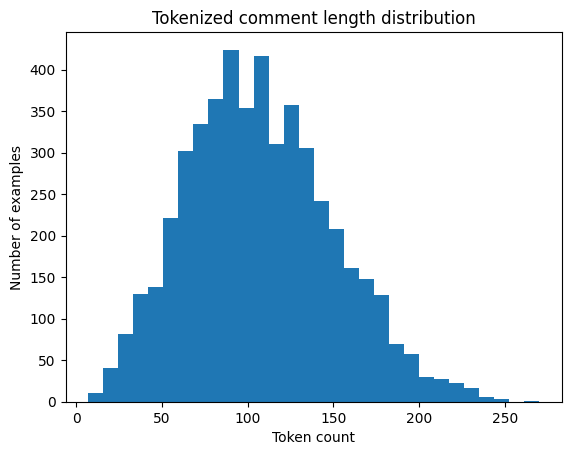

In [25]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
token_lengths = [len(tokenizer(x)['input_ids']) for x in dataset['train']['clean_text']]

print("Median:", np.median(token_lengths))
print("90th percentile:", np.percentile(token_lengths, 90))
print("95th percentile:", np.percentile(token_lengths, 95))
print("Max:", max(token_lengths))

import matplotlib.pyplot as plt
plt.hist(token_lengths, bins=30)
plt.xlabel("Token count")
plt.ylabel("Number of examples")
plt.title("Tokenized comment length distribution")
plt.show()

def tokenize_fn(examples):
    return tokenizer(examples['clean_text'], truncation=True, padding='max_length', max_length=192)

tokenized_dataset = dataset.map(tokenize_fn, batched=True)

In [26]:
label2id = {'NOT': 0, 'HOF': 1}
tokenized_dataset = tokenized_dataset.map(lambda x: {'label': label2id[x['binary class']]})
tokenized_dataset = tokenized_dataset.cast_column('label', ClassLabel(names=['NOT', 'HOF']))

In [27]:
full_split = tokenized_dataset['train'].train_test_split(test_size=0.15, stratify_by_column='label', seed=42)
train_val_ds = full_split['train']
test_ds = full_split['test']

train_val_split = train_val_ds.train_test_split(test_size=0.15, stratify_by_column='label', seed=42)
train_ds = train_val_split['train']
val_ds = train_val_split['test']

print(len(train_ds), len(val_ds), len(test_ds))

3549 627 738


In [28]:
train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

In [29]:
teacher_model = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=2)

training_args = TrainingArguments(
    output_dir=f"{project_dir}/teacher_model",   # <-- changed
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="wandb",
    run_name="teacher-xlmr-hasoc"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="macro"),
        "precision": precision_score(labels, predictions, average="macro"),
        "recall": recall_score(labels, predictions, average="macro"),
    }

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
trainer = Trainer(
    model=teacher_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

In [31]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.676507,0.585327,0.545784,0.651356,0.593763
2,No log,0.569914,0.695375,0.695263,0.697104,0.696406
3,0.646621,0.528721,0.732057,0.731904,0.731876,0.731947
4,0.646621,0.534763,0.748006,0.747954,0.749541,0.748946


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=888, training_loss=0.5886878967285156, metrics={'train_runtime': 878.8103, 'train_samples_per_second': 16.154, 'train_steps_per_second': 1.01, 'total_flos': 1400671703208960.0, 'train_loss': 0.5886878967285156, 'epoch': 4.0})

In [32]:
test_results = trainer.evaluate(test_ds)
print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.646621,0.562886,4,0.726287,0.726215,0.726220,0.726380


{'eval_loss': 0.5628857016563416, 'eval_accuracy': 0.7262872628726287, 'eval_f1': 0.7262148760330578, 'eval_precision': 0.7262204660795992, 'eval_recall': 0.726380079523155}


In [33]:
trainer.save_model(f"{project_dir}/saved_teacher")
tokenizer.save_pretrained(f"{project_dir}/saved_teacher")

os.listdir(f"{project_dir}/saved_teacher")  # verify it worked

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['config.json',
 'model.safetensors',
 'training_args.bin',
 'tokenizer_config.json',
 'tokenizer.json']

In [57]:
import shutil
shutil.rmtree(f"{project_dir}/teacher_model", ignore_errors=True)
shutil.rmtree(f"{project_dir}/student_results", ignore_errors=True)
shutil.rmtree(f"{project_dir}/student_diag", ignore_errors=True)

In [34]:
predictions_output = trainer.predict(test_ds)
preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

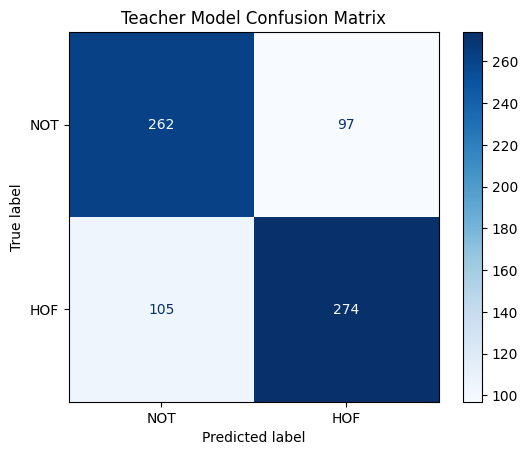

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NOT', 'HOF'])
disp.plot(cmap='Blues')
plt.title("Teacher Model Confusion Matrix")
plt.show()

In [36]:
print(test_ds.column_names)

['rawtweets', 'binary class', 'Context class', 'cleaned Tweets', 'clean_text', 'input_ids', 'attention_mask', 'label']


In [37]:
test_ds.reset_format()
texts = test_ds['clean_text']
true_binary = test_ds['binary class']
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

In [38]:
test_ds.reset_format()

texts = test_ds['clean_text']
true_binary = test_ds['binary class']

test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

In [39]:
test_ds.reset_format()

texts = list(test_ds['clean_text'])
true_binary = list(test_ds['binary class'])

test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

In [40]:
import pandas as pd

results_df = pd.DataFrame({
    'text': texts,
    'true_label': true_binary,
    'predicted_label': ['HOF' if p == 1 else 'NOT' for p in preds],
})

In [41]:
false_positives = results_df[(results_df['true_label'] == 'NOT') & (results_df['predicted_label'] == 'HOF')]
print(f"Number of false positives: {len(false_positives)}")

for i, row in false_positives.head(15).iterrows():
    print(row['text'])
    print("---")

Number of false positives: 97
fahedalemadi naveenjindalbjp मज़ा आ रहा है naveenjindalbjp अरब से गाली सुन कर तुम्हारे माँ बाप आज शर्मिंदा होंगे तुम जैसे कुकर्मी बेटे को जन्म दे कर। COMMENT AAPNareshBalyan fahedalemadi naveenjindalbjp Janab Balyan. Punjab me Punjab Police ke sanrakshan me Kahlistani raste pe utar aaye hain. Financier ko kiya hua waada khoob nibha rahe hain saarey Paapiye. Punjab ko Funjab bananey ke like mubarak .
---
No nation can claim itself to be safe if the security of its own PM gets compromised. I condemn in the strongest words possible the cowardly attack on PM Modi by anarchists. BharatStandsWithModi PMModi COMMENT NSaina Ye tour programme tha to fir change kyun kiya
---
There was communal tension in Tripura but controlled by police some days ago Propagandists spread fake news in name of Tripura violence which resulted in violence by radicals in Maharashtra These photos videos are not from Tripura video from Bangladesh &amp photos of Rohingyas COMMENT AskAnshul 

In [42]:
false_negatives = results_df[(results_df['true_label'] == 'HOF') & (results_df['predicted_label'] == 'NOT')]
print(f"Number of false negatives: {len(false_negatives)}")

for i, row in false_negatives.head(15).iterrows():
    print(row['text'])
    print("---")

Number of false negatives: 105
President Kovind presents Padma Shri to Ms Kangana Ranaut for Art. She is an Indian film actress and filmmaker who is widely recognised as an actress par excellence. COMMENT rashtrapatibhvn Nobody knows this woman outside India. Even if they do its all for the wrong reasons.
---
President Kovind presents Padma Shri to Ms Kangana Ranaut for Art. She is an Indian film actress and filmmaker who is widely recognised as an actress par excellence. COMMENT rashtrapatibhvn She truly deserves ♥️ REPLY-COMMENT Bipinkrfan rashtrapatibhvn फर्जी id से ही हो सकता डिज़र्व
---
Sad to see a poet and writer spitting venom using dubious and imaginary arguments as history. COMMENT irfhabib Moorkh hai.
---
Taimur - invader Jehangir - settler kinda following the progression next should be Iqbal or Jinnah
---
India never existed before the British - Saif Ali Khan Mughals were the builders of India - Kabir Khan Is it education or DNA 🧬 JustAsking
---
Is it the first time Islamic

In [43]:
from transformers import AutoTokenizer

student_checkpoint = "distilbert-base-multilingual-cased"
student_tokenizer = AutoTokenizer.from_pretrained(student_checkpoint)


def tokenize_for_student(batch):
    return student_tokenizer(
        batch['clean_text'],  # Changed 'text' to 'clean_text'
        truncation=True,
        max_length=192,
        padding="max_length",
    )

student_train_ds = train_ds.map(tokenize_for_student, batched=True)
student_val_ds   = val_ds.map(tokenize_for_student, batched=True)
student_test_ds  = test_ds.map(tokenize_for_student, batched=True)

# Set format so PyTorch/Trainer gets tensors back
cols = ["input_ids", "attention_mask", "label"] # Changed 'labels' to 'label'
student_train_ds.set_format(type="torch", columns=cols)
student_val_ds.set_format(type="torch", columns=cols)
student_test_ds.set_format(type="torch", columns=cols)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/3549 [00:00<?, ? examples/s]

Map:   0%|          | 0/627 [00:00<?, ? examples/s]

Map:   0%|          | 0/738 [00:00<?, ? examples/s]

In [44]:
print(student_train_ds[0])

{'input_ids': tensor([   101,  24852,  65984,  19737,  10142,  32992,  90939,  11490,  37923,
         19779,  62319,    119,  64129,  12141,  10160,  11816,    119,  14535,
         13028,  10529,  10678,  10708,  20637,  10169,  10911,  10106,  10105,
         12469,  11003,  13990,  10111,  10529,  62319,  20648,  42658,  10112,
         48394,  19436,  53426,    119,  22034,  19540,  71560,    118,  11131,
         14446,    119,  71547,    119,  69189,  12022,  10410,  11281,  58563,
         80645,  42424,  77261,  10118,  18111,  32066,  10136,  18573,  56570,
         10230,  13028,    169,  19085,  10157,  61958,  22678,  10114,  45567,
         15174,  10114,  24944,  10939,  10105, 106750,    100,  71033,  11127,
         11369,  14703,    118,  80645,  42424,  77261,  13352,  38806,  10219,
         10731,  71784,  10112,  10118,  18111,  32066,  10136,  18573,  18082,
         10162,  10957,  11152,  15174,  10135,  72445,  10111,  10446,  26342,
           102,      0,   

In [45]:
import os
os.listdir(f"{project_dir}/saved_teacher")

['config.json',
 'model.safetensors',
 'training_args.bin',
 'tokenizer_config.json',
 'tokenizer.json']

In [46]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

device = "cuda" if torch.cuda.is_available() else "cpu"

In [47]:
teacher_model = AutoModelForSequenceClassification.from_pretrained(f"{project_dir}/saved_teacher")
teacher_model.to(device)
teacher_model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=2, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [48]:
student_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased", num_labels=2
)
student_model.to(device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  542MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)

In [49]:
class DistillationTrainer(Trainer):
    def __init__(self, *args, teacher_model=None, temperature=2.0, alpha=0.5, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model
        self.teacher_model.eval()
        self.temperature = temperature
        self.alpha = alpha

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]

        student_outputs = model(**inputs)
        student_logits = student_outputs.logits


        with torch.no_grad():
            teacher_outputs = self.teacher_model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"]
            )
            teacher_logits = teacher_outputs.logits


        student_log_probs = F.log_softmax(student_logits / self.temperature, dim=-1)
        teacher_probs = F.softmax(teacher_logits / self.temperature, dim=-1)

        distill_loss = F.kl_div(
            student_log_probs,
            teacher_probs,
            reduction="batchmean"
        ) * (self.temperature ** 2)


        hard_loss = F.cross_entropy(student_logits, labels)


        loss = self.alpha * distill_loss + (1 - self.alpha) * hard_loss

        return (loss, student_outputs) if return_outputs else loss

In [50]:
training_args = TrainingArguments(
    output_dir="./student_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

In [51]:
import transformers
print(transformers.__version__)

5.16.1


In [59]:

student_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased", num_labels=2
)
student_model.to(device)

training_args = TrainingArguments(
    output_dir=f"{project_dir}/student_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

distil_trainer = DistillationTrainer(
    model=student_model,
    args=training_args,
    train_dataset=student_train_ds,
    eval_dataset=student_val_ds,
    teacher_model=teacher_model,
    temperature=1.0,
    alpha=0.3,
    compute_metrics=compute_metrics,
)

distil_trainer.train()
distil_trainer.evaluate(student_test_ds)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.485348,0.693780,0.691405,0.704934,0.696670
2,No log,0.473984,0.711324,0.708089,0.727386,0.714703
3,0.480898,0.463222,0.725678,0.724820,0.732026,0.727726


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.480898,0.488538,3,0.703252,0.702854,0.706689,0.704761


{'eval_loss': 0.4885382056236267,
 'eval_accuracy': 0.7032520325203252,
 'eval_f1': 0.7028543062794739,
 'eval_precision': 0.7066888242625675,
 'eval_recall': 0.7047610998008247}

In [54]:
diag_training_args = TrainingArguments(
    output_dir="./student_diag",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

# fresh student, not the one you already trained
diag_student_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased", num_labels=2
)
diag_student_model.to(device)

diag_trainer = DistillationTrainer(
    model=diag_student_model,
    args=diag_training_args,
    train_dataset=student_train_ds,
    eval_dataset=student_val_ds,
    teacher_model=teacher_model,
    temperature=1.0,
    alpha=0.0,   # <-- pure hard loss, teacher signal contributes nothing
    compute_metrics=compute_metrics,
)

diag_trainer.train()
diag_trainer.evaluate(student_test_ds)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.556664,0.682616,0.682499,0.682487,0.682599
2,No log,0.536394,0.717703,0.717139,0.722295,0.719443
3,0.549885,0.525802,0.743222,0.743156,0.743162,0.743336


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.549885,0.573111,3,0.708672,0.708337,0.708466,0.708274


{'eval_loss': 0.5731111764907837,
 'eval_accuracy': 0.7086720867208672,
 'eval_f1': 0.708337392627831,
 'eval_precision': 0.7084657485875706,
 'eval_recall': 0.7082742299409823}

In [60]:
class FilteredDistillationTrainer(Trainer):
    def __init__(self, *args, teacher_model=None, temperature=1.0, alpha=0.3, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model
        self.teacher_model.eval()
        self.temperature = temperature
        self.alpha = alpha

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]

        student_outputs = model(**inputs)
        student_logits = student_outputs.logits

        with torch.no_grad():
            teacher_outputs = self.teacher_model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"]
            )
            teacher_logits = teacher_outputs.logits
            teacher_preds = torch.argmax(teacher_logits, dim=-1)

        # Mask: True where teacher's prediction matches the real label
        teacher_correct_mask = (teacher_preds == labels)

        # --- Hard loss: applied to ALL examples, same as before ---
        hard_loss = F.cross_entropy(student_logits, labels)

        # --- Distillation loss: only computed on teacher-correct examples ---
        if teacher_correct_mask.sum() > 0:
            student_log_probs = F.log_softmax(
                student_logits[teacher_correct_mask] / self.temperature, dim=-1
            )
            teacher_probs = F.softmax(
                teacher_logits[teacher_correct_mask] / self.temperature, dim=-1
            )
            distill_loss = F.kl_div(
                student_log_probs,
                teacher_probs,
                reduction="batchmean"
            ) * (self.temperature ** 2)
        else:
            # Rare edge case: no teacher-correct examples in this batch
            distill_loss = torch.tensor(0.0, device=student_logits.device)

        loss = self.alpha * distill_loss + (1 - self.alpha) * hard_loss

        return (loss, student_outputs) if return_outputs else loss

In [61]:
student_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased", num_labels=2
)
student_model.to(device)

training_args = TrainingArguments(
    output_dir=f"{project_dir}/student_filtered",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

filtered_trainer = FilteredDistillationTrainer(
    model=student_model,
    args=training_args,
    train_dataset=student_train_ds,
    eval_dataset=student_val_ds,
    teacher_model=teacher_model,
    temperature=1.0,
    alpha=0.3,
    compute_metrics=compute_metrics,
)

filtered_trainer.train()
filtered_trainer.evaluate(student_test_ds)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.457803,0.690590,0.690015,0.694621,0.692267
2,No log,0.434055,0.714514,0.712831,0.724240,0.717116
3,0.454245,0.424998,0.746411,0.746039,0.750509,0.747999


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.454245,0.465508,3,0.692412,0.692208,0.694679,0.693619


{'eval_loss': 0.4655083417892456,
 'eval_accuracy': 0.6924119241192412,
 'eval_f1': 0.6922079138977333,
 'eval_precision': 0.6946792787466746,
 'eval_recall': 0.6936190385194876}

In [62]:
diag_trainer.evaluate(student_test_ds)

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.549885,0.573111,3,0.708672,0.708337,0.708466,0.708274


{'eval_loss': 0.5731111764907837,
 'eval_accuracy': 0.7086720867208672,
 'eval_f1': 0.708337392627831,
 'eval_precision': 0.7084657485875706,
 'eval_recall': 0.7082742299409823}

In [63]:
print(project_dir)

/content/drive/MyDrive/hasoc_project


In [64]:
diag_trainer.save_model(f"{project_dir}/saved_student")
student_tokenizer.save_pretrained(f"{project_dir}/saved_student")
os.listdir(f"{project_dir}/saved_student")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['config.json',
 'model.safetensors',
 'training_args.bin',
 'tokenizer_config.json',
 'tokenizer.json']

In [68]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

teacher_params = count_params(teacher_model)
student_params = count_params(diag_student_model)  # your final student

print(f"Teacher (XLM-R) params: {teacher_params:,}")
print(f"Student (DistilBERT) params: {student_params:,}")
print(f"Size reduction: {(1 - student_params/teacher_params)*100:.1f}%")

Teacher (XLM-R) params: 278,045,186
Student (DistilBERT) params: 135,326,210
Size reduction: 51.3%


In [69]:
import time

def measure_latency(model, tokenizer, text, device, n_runs=50):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=192, padding="max_length").to(device)

    # warm-up runs (first few are always slower, exclude from timing)
    with torch.no_grad():
        for _ in range(5):
            _ = model(**inputs)

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(**inputs)
    if device == "cuda":
        torch.cuda.synchronize()
    end = time.time()

    avg_latency_ms = ((end - start) / n_runs) * 1000
    return avg_latency_ms

sample_text = test_ds[0]["clean_text"]  # or any representative example

teacher_latency = measure_latency(teacher_model, tokenizer, sample_text, device)
student_latency = measure_latency(diag_student_model, student_tokenizer, sample_text, device)

print(f"Teacher avg latency: {teacher_latency:.2f} ms/prediction")
print(f"Student avg latency: {student_latency:.2f} ms/prediction")
print(f"Speedup: {teacher_latency/student_latency:.2f}x")

KeyError: 'clean_text'

In [70]:
print(test_ds.column_names)

['rawtweets', 'binary class', 'Context class', 'cleaned Tweets', 'clean_text', 'input_ids', 'attention_mask', 'label']


In [71]:
test_ds.reset_format()
sample_text = test_ds[0]["clean_text"]
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [72]:
teacher_latency = measure_latency(teacher_model, tokenizer, sample_text, device)
student_latency = measure_latency(diag_student_model, student_tokenizer, sample_text, device)

print(f"Teacher avg latency: {teacher_latency:.2f} ms/prediction")
print(f"Student avg latency: {student_latency:.2f} ms/prediction")
print(f"Speedup: {teacher_latency/student_latency:.2f}x")

Teacher avg latency: 96.43 ms/prediction
Student avg latency: 23.48 ms/prediction
Speedup: 4.11x


In [73]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

teacher_params = count_params(teacher_model)
student_params = count_params(diag_student_model)

print(f"Teacher (XLM-R) params: {teacher_params:,}")
print(f"Student (DistilBERT) params: {student_params:,}")
print(f"Size reduction: {(1 - student_params/teacher_params)*100:.1f}%")


Teacher (XLM-R) params: 278,045,186
Student (DistilBERT) params: 135,326,210
Size reduction: 51.3%


In [74]:
teacher_f1 = 0.7369
student_f1 = 0.7080

performance_retained = (student_f1 / teacher_f1) * 100
print(f"Student retains {performance_retained:.1f}% of teacher's macro-F1")

Student retains 96.1% of teacher's macro-F1


In [2]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"

from google.colab import drive
drive.mount('/content/drive')
project_dir = "/content/drive/MyDrive/hasoc_project"

teacher_model = AutoModelForSequenceClassification.from_pretrained(f"{project_dir}/saved_teacher")
tokenizer = AutoTokenizer.from_pretrained(f"{project_dir}/saved_teacher")
teacher_model.to(device)
teacher_model.eval()

diag_student_model = AutoModelForSequenceClassification.from_pretrained(f"{project_dir}/saved_student")
student_tokenizer = AutoTokenizer.from_pretrained(f"{project_dir}/saved_student")
diag_student_model.to(device)
diag_student_model.eval()

Mounted at /content/drive


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)

In [3]:
import gradio as gr
import time

teacher_model.to(device)
teacher_model.eval()
diag_student_model.to(device)
diag_student_model.eval()

label_map = {0: "NOT", 1: "HOF"}
verdict_word = {0: "Clear", 1: "Flagged"}

custom_css = """
@import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Serif:wght@400;600&family=IBM+Plex+Sans:wght@400;500&display=swap');

.gradio-container {
    background: #F6F3EC !important;
    font-family: 'IBM Plex Sans', sans-serif !important;
    max-width: 900px !important;
    --body-text-color: #1B1A17 !important;
    --body-text-color-subdued: #6B6558 !important;
    --block-label-text-color: #1B1A17 !important;
    --block-title-text-color: #1B1A17 !important;
    --block-background-fill: #F6F3EC !important;
    --background-fill-primary: #F6F3EC !important;
    --background-fill-secondary: #F6F3EC !important;
    --border-color-primary: #D8D3C7 !important;
}

.gradio-container, .gradio-container p, .gradio-container span,
.gradio-container label, .gradio-container div {
    color: #1B1A17;
}

#title-block h1 {
    font-family: 'IBM Plex Serif', serif !important;
    font-weight: 600 !important;
    font-size: 1.9rem !important;
    color: #1B1A17 !important;
    margin-bottom: 0.1em !important;
}

#title-block p {
    color: #6B6558 !important;
    font-size: 0.95rem !important;
    border-top: 1px solid #D8D3C7;
    padding-top: 10px;
    margin-top: 6px !important;
}

#input-row textarea {
    background: #FFFFFF !important;
    border: 1px solid #C9C3B4 !important;
    border-radius: 2px !important;
    color: #1B1A17 !important;
    box-shadow: none !important;
}

#analyze-btn {
    background: #1B1A17 !important;
    color: #F6F3EC !important;
    border-radius: 2px !important;
    border: none !important;
    font-weight: 500 !important;
}
#analyze-btn:hover { background: #3A3833 !important; }

.verdict-line {
    font-family: 'IBM Plex Serif', serif !important;
    font-size: 1.05rem !important;
    text-align: center;
    padding: 10px 0 !important;
    border-top: 1px solid #D8D3C7;
    border-bottom: 1px solid #D8D3C7;
    margin: 14px 0 !important;
    color: #1B1A17 !important;
}
.verdict-line strong { color: #1B1A17 !important; }

.panel { padding: 4px 20px !important; }
.panel-left { border-right: 1px solid #D8D3C7 !important; }

.panel h3 {
    font-family: 'IBM Plex Serif', serif !important;
    font-weight: 600 !important;
    font-size: 1.05rem !important;
    margin-bottom: 2px !important;
    color: #1B1A17 !important;
}
.panel .meta { color: #6B6558 !important; font-size: 0.85rem !important; margin-bottom: 10px !important; }
.panel p { color: #1B1A17 !important; }

.stamp-hof { color: #A6402F !important; font-weight: 600; }
.stamp-not { color: #3C5B43 !important; font-weight: 600; }

/* Examples table + its label */
.gradio-container .label-wrap span,
.gradio-container .gallery,
.gradio-container table, .gradio-container td, .gradio-container th {
    color: #1B1A17 !important;
}
.gradio-container table {
    background: #FFFFFF !important;
    font-size: 0.9rem !important;
}
.gradio-container td {
    background: #FFFFFF !important;
    border-color: #D8D3C7 !important;
}

footer { display: none !important; }
"""

def predict_both(text):
    if not text.strip():
        return "", "", "Enter text above and press Analyze."

    teacher_inputs = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=192, padding="max_length"
    ).to(device)
    start = time.time()
    with torch.no_grad():
        teacher_logits = teacher_model(**teacher_inputs).logits
    teacher_time = (time.time() - start) * 1000
    teacher_probs = F.softmax(teacher_logits, dim=-1)[0]
    teacher_pred = torch.argmax(teacher_probs).item()

    student_inputs = student_tokenizer(
        text, return_tensors="pt", truncation=True, max_length=192, padding="max_length"
    ).to(device)
    start = time.time()
    with torch.no_grad():
        student_logits = diag_student_model(**student_inputs).logits
    student_time = (time.time() - start) * 1000
    student_probs = F.softmax(student_logits, dim=-1)[0]
    student_pred = torch.argmax(student_probs).item()

    def panel(name, params, pred, conf, ms):
        stamp_class = "stamp-hof" if pred == 1 else "stamp-not"
        return f"""
<div class="panel">
<h3>{name}</h3>
<p class="meta">{params} parameters</p>
<p><span class="{stamp_class}">{verdict_word[pred]}</span> — {conf*100:.1f}% confidence</p>
<p class="meta">{ms:.1f} ms</p>
</div>
"""

    teacher_panel = panel("XLM-RoBERTa (teacher)", "278M", teacher_pred, teacher_probs[teacher_pred].item(), teacher_time)
    student_panel = panel("DistilBERT (student)", "135M", student_pred, student_probs[student_pred].item(), student_time)

    if teacher_pred == student_pred:
        verdict = f'<div class="verdict-line">Both models agree — <strong>{verdict_word[teacher_pred]}</strong>. Student ran {teacher_time/student_time:.1f}x faster.</div>'
    else:
        verdict = f'<div class="verdict-line">Models disagree — teacher says <strong>{verdict_word[teacher_pred]}</strong>, student says <strong>{verdict_word[student_pred]}</strong>.</div>'

    return teacher_panel, student_panel, verdict

with gr.Blocks(css=custom_css, theme=gr.themes.Base()) as demo:
    with gr.Column(elem_id="title-block"):
        gr.Markdown("# Code-mixed hate speech detector")
        gr.Markdown("Two models, same text: a fine-tuned XLM-RoBERTa teacher and a distilled DistilBERT student, trained on the HASOC 2021 Hindi-English code-mixed benchmark.")

    with gr.Row(elem_id="input-row"):
        text_input = gr.Textbox(
            label="",
            placeholder="Paste Hindi-English code-mixed text here",
            lines=3,
            scale=5
        )
    analyze_btn = gr.Button("Analyze", elem_id="analyze-btn")

    verdict_html = gr.HTML()

    with gr.Row():
        with gr.Column(elem_classes="panel-left"):
            teacher_html = gr.HTML()
        with gr.Column():
            student_html = gr.HTML()

    gr.Examples(
        examples=[
            ["Yeh sarkar sirf vote bank ki rajneeti kar rahi hai"],
            ["Country needs Detox Prime Ministry busy giving Botox. COMMENT kunalkamra88 Country needs dettol.. तुझ जैसे कीटाणु जो घूम रहे"],
        ],
        inputs=text_input,
        label="Try a real example from the test set"
    )

    gr.Markdown(
        """
Both models tend to over-flag politically or religiously charged language even in ordinary discussion, and can miss subtle coded hate that avoids explicit slurs — see the project README for full error analysis.

| | Teacher | Student |
|---|---|---|
| Parameters | 278M | 135M |
| Latency | 96.4 ms | 23.5 ms |
| Macro-F1 (test) | 73.69% | 70.80% |
"""
    )

    analyze_btn.click(predict_both, inputs=text_input, outputs=[teacher_html, student_html, verdict_html])
    text_input.submit(predict_both, inputs=text_input, outputs=[teacher_html, student_html, verdict_html])

demo.launch(share=True)

/tmp/ipykernel_4295/4285987986.py:158: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Base()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9f73708c76fe9f0b01.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [76]:
false_negatives = results_df[(results_df['true_label'] == 'HOF') & (results_df['predicted_label'] == 'NOT')].copy()

def student_predict(text):
    inputs = student_tokenizer(
        text, return_tensors="pt", truncation=True, max_length=192, padding="max_length"
    ).to(device)
    with torch.no_grad():
        logits = diag_student_model(**inputs).logits
    pred = torch.argmax(logits, dim=-1).item()
    return "HOF" if pred == 1 else "NOT"

false_negatives["student_prediction"] = false_negatives["text"].apply(student_predict)

student_caught = (false_negatives["student_prediction"] == "HOF").sum()
total_fn = len(false_negatives)

print(f"Teacher's false negatives: {total_fn}")
print(f"Student correctly caught: {student_caught} ({student_caught/total_fn*100:.1f}%)")
print(f"Student also missed: {total_fn - student_caught} ({(total_fn - student_caught)/total_fn*100:.1f}%)")

Teacher's false negatives: 105
Student correctly caught: 32 (30.5%)
Student also missed: 73 (69.5%)


In [77]:
false_positives = results_df[(results_df['true_label'] == 'NOT') & (results_df['predicted_label'] == 'HOF')].copy()

false_positives["student_prediction"] = false_positives["text"].apply(student_predict)

student_correct_on_fp = (false_positives["student_prediction"] == "NOT").sum()
total_fp = len(false_positives)

print(f"Teacher's false positives: {total_fp}")
print(f"Student correctly avoided: {student_correct_on_fp} ({student_correct_on_fp/total_fp*100:.1f}%)")
print(f"Student also over-flagged: {total_fp - student_correct_on_fp} ({(total_fp - student_correct_on_fp)/total_fp*100:.1f}%)")


Teacher's false positives: 97
Student correctly avoided: 28 (28.9%)
Student also over-flagged: 69 (71.1%)


In [4]:
teacher_model.push_to_hub("Bharath2kk5/hasoc-teacher-xlmr")
tokenizer.push_to_hub("Bharath2kk5/hasoc-teacher-xlmr")

student_model.push_to_hub("Bharath2kk5/hasoc-student-distilbert")
student_tokenizer.push_to_hub("Bharath2kk5/hasoc-student-distilbert")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...2e8q3ur/model.safetensors:   0%|          |  561kB / 1.11GB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpbvsvnppq/tokenizer.json: 100%|##########| 17.1MB / 17.1MB            

NameError: name 'student_model' is not defined

In [5]:
from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

In [6]:
print(teacher_model)

XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=2, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [7]:
teacher_model.push_to_hub("Bharath2kk5/hasoc-teacher-xlmr")
tokenizer.push_to_hub("Bharath2kk5/hasoc-teacher-xlmr")

diag_student_model.push_to_hub("Bharath2kk5/hasoc-student-distilbert")
student_tokenizer.push_to_hub("Bharath2kk5/hasoc-student-distilbert")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...7va0av6/model.safetensors:   2%|2         | 24.0MB / 1.11GB            

No files have been modified since last commit. Skipping to prevent empty commit.


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...fx1140o/model.safetensors:   0%|          | 10.2kB /  541MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Bharath2kk5/hasoc-student-distilbert/commit/e35adc08bfa8769c82edc12f102b85ddd40119fc', commit_message='Upload tokenizer', commit_description='', oid='e35adc08bfa8769c82edc12f102b85ddd40119fc', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Bharath2kk5/hasoc-student-distilbert', endpoint='https://huggingface.co', repo_type='model', repo_id='Bharath2kk5/hasoc-student-distilbert'), pr_revision=None, pr_num=None)